## MAE-6286 Lesson 3

**Instructor version with solution**

Full phugoid system of equations:
$$
u=
\begin{bmatrix}
v\\ \theta\\ x\\ y
\end{bmatrix},
\qquad
u'=f(u)=
\begin{bmatrix}
-g\sin\theta-\dfrac{C_D}{C_L}\dfrac{g}{v_t^2}v^2\\
-\dfrac{g}{v}\cos\theta+\dfrac{g}{v_t^2}v\\
v\cos\theta\\
v\sin\theta
\end{bmatrix}.
$$

In vector form, one Forward Euler step is simply

$$
u^{n+1}=u^n+\Delta t\,f(u^n).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Model parameters.
g = 9.81        # gravitational acceleration (m/s**2)
v_t = 30.0      # trim speed (m/s)
C_D = 1. / 40.  # drag coefficient
C_L = 1.0       # lift coefficient

# Initial conditions.
v_0 = v_t      # speed (m/s)
theta_0 = 0.0  # trajectory angle (rad)
x_0 = 0.0      # horizontal position (m)
y_0 = 1000.0   # altitude (m)

In [3]:
def rhs_full_phugoid(u, C_L, C_D, g, v_t):
    '''Return the derivatives for the nonlinear, damped phugoid model.

    Parameters
    ----------
    u : np.ndarray
        State vector [v, theta, x, y].
    C_L : float
        Lift coefficient.
    C_D : float
        Drag coefficient.
    g : float
        Gravitational acceleration.
    v_t : float
        Trim speed.

    Returns
    -------
    np.ndarray
        Derivative vector [dv/dt, dtheta/dt, dx/dt, dy/dt].
    '''
    v, theta, x, y = u
    return np.array([
        -g * np.sin(theta) - (C_D / C_L) * (g / v_t**2) * v**2,
        -(g / v) * np.cos(theta) + (g / v_t**2) * v,
        v * np.cos(theta),
        v * np.sin(theta),
    ])


In [4]:
def euler_step(u, f, dt, *args):
    '''Return the next state using one Forward Euler step.

    Parameters
    ----------
    u : np.ndarray
        State at the current time.
    f : callable
        Function that returns the state derivatives.
    dt : float
        Time-step size.
    *args
        Additional positional arguments passed to f.

    Returns
    -------
    np.ndarray
        State after one Forward Euler step.
    '''
    return u + dt * f(u, *args)
    

In [5]:
T = 100.0  # length of the time interval (s)
dt = 0.1   # time-step size (s)
num_steps = int(round(T / dt))
t = np.linspace(0.0, T, num=num_steps + 1)

# Store [v, theta, x, y] at every time step.
u_history = np.empty((num_steps + 1, 4))
u_history[0] = np.array([v_0, theta_0, x_0, y_0])

for n in range(num_steps):
    u_history[n + 1] = euler_step(
        u_history[n], rhs_full_phugoid, dt, C_L, C_D, g, v_t
    )


In [6]:
x = u_history[:, 2]
y = u_history[:, 3]


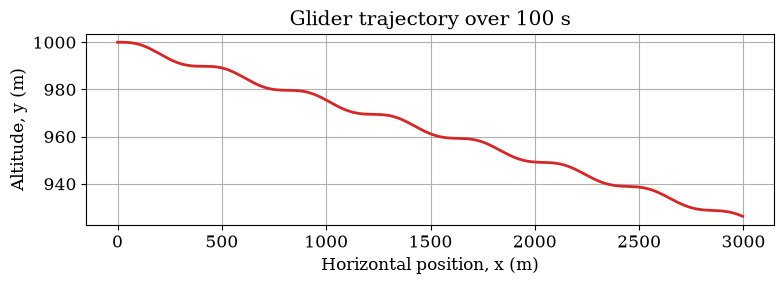

In [7]:
# Set the font family and size to use for Matplotlib figures.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(8,3))

ax.set_title(f'Glider trajectory over {T:g} s')
ax.set_xlabel('Horizontal position, x (m)')
ax.set_ylabel('Altitude, y (m)')
ax.grid()
ax.plot(x, y, color='tab:red', linestyle='-', linewidth=2)
fig.tight_layout()


In [8]:
dt_values = [0.1, 0.05, 0.01, 0.005, 0.001]
u_histories = [] # an empty list for the solution on each grid

for dt_trial in dt_values:
    num_steps_trial = int(round(T / dt_trial))
    u_trial = np.empty((num_steps_trial + 1, 4))
    u_trial[0] = np.array([v_0, theta_0, x_0, y_0])

    for n in range(num_steps_trial):
        u_trial[n + 1] = euler_step(
            u_trial[n],
            rhs_full_phugoid,
            dt_trial,
            C_L,
            C_D,
            g,
            v_t,
        )

    u_histories.append(u_trial)


In [9]:
def discrete_l1_difference(
    q_coarse, q_fine, dt_coarse, dt_fine
):
    '''Return a discrete L1 difference on two nested time grids.'''
    refinement_ratio = int(round(dt_coarse / dt_fine))

    if not np.isclose(
        dt_coarse, refinement_ratio * dt_fine
    ):
        raise ValueError('Time-step sizes do not define nested grids.')

    q_fine_on_coarse_grid = q_fine[::refinement_ratio]

    if q_fine_on_coarse_grid.shape != q_coarse.shape:
        raise ValueError('Grid endpoints or sample counts do not align.')

    return dt_coarse * np.sum(
        np.abs(q_coarse - q_fine_on_coarse_grid)
    )


In [10]:
dt_reference = dt_values[-1]
x_reference = u_histories[-1][:, 2]
difference_values = []

for dt_trial, u_trial in zip(
    dt_values[:-1], u_histories[:-1], strict=True
):
    x_trial = u_trial[:, 2]
    difference_values.append(
        discrete_l1_difference(
            x_trial,
            x_reference,
            dt_trial,
            dt_reference,
        )
    )


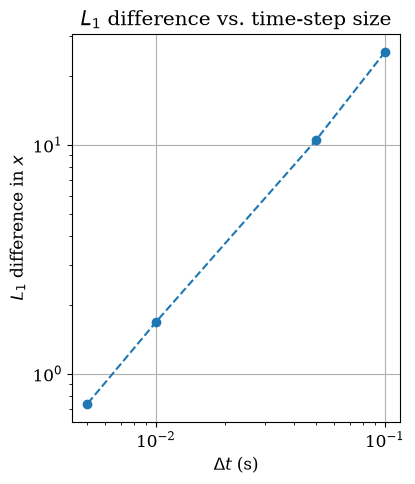

In [11]:
dt_array = np.array(dt_values[:-1])

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.set_title(r'$L_1$ difference vs. time-step size')
ax.set_xlabel(r'$\Delta t$ (s)')
ax.set_ylabel(r'$L_1$ difference in $x$')
ax.grid()
ax.loglog(
    dt_array,
    difference_values,
    color='tab:blue',
    linestyle='--',
    marker='o',
)
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()


### Agent observed-order task brief

- **Goal and scope:** Add and execute new cells in my notebook named `lesson3-agent-demo.ipynb` to estimate the observed order of convergence of horizontal position $x(t)$ for the existing full-phugoid Forward Euler calculation. Investigate only this claim. Do not attempt to verify the physical model, introduce another integrator, or extend the study to the paper-airplane challenge.

- **Non-negotiables:** Use refinement ratio $r=2$ and step sizes $0.001$, $0.002$, and $0.004$ seconds, ordered fine, medium, and coarse. Integrate every grid from $t=0$ to the existing `T` using the existing initial state, `rhs_full_phugoid()`, `euler_step()`, `C_L`, `C_D`, `g`, and `v_t`. Compare horizontal position, element 2 of the state history. Calculate $D_{21}$ by passing the medium and fine histories to `discrete_l1_difference()`, and calculate $D_{32}$ from the coarse and medium histories. Calculate
$$p=
\frac{\log(D_{32}/D_{21})}{\log r}.
$$
 Do not hard-code a value of $p$, change the experiment to obtain the expected result, use an exact solution, interpolate grids, use SciPy, or modify any existing function or data.

- **Allowed actions:** Read the attached notebook, add new code cells immediately after the task brief, execute the existing prerequisite cells and the new cells locally, and revise only the cells you add if they fail. Do not modify, delete, or reorder existing cells. Do not install packages, access the network, or change any other file.

- **Done when:** All three integrations reach the existing final time and the new cells execute without error. Display the fine, medium, and coarse step sizes and step counts; $D_{21}$; $D_{32}$; $D_{32}/D_{21}$; and $p$, with enough precision to check the arithmetic. Return a short record of the cells added, whether they executed successfully, and the exact numerical output. Report unexpected results rather than changing the specification. Do not make the final accept/revise/reject decision for me.

In [12]:
r = 2
dt_fine, dt_medium, dt_coarse = 0.001, 0.002, 0.004
observed_order_histories = {}
observed_order_step_counts = {}

for grid_name, dt_trial in (
    ('fine', dt_fine),
    ('medium', dt_medium),
    ('coarse', dt_coarse),
):
    num_steps_trial = int(round(T / dt_trial))
    u_trial = np.empty((num_steps_trial + 1, 4))
    u_trial[0] = np.array([v_0, theta_0, x_0, y_0])

    for n in range(num_steps_trial):
        u_trial[n + 1] = euler_step(
            u_trial[n], rhs_full_phugoid, dt_trial, C_L, C_D, g, v_t
        )

    observed_order_histories[grid_name] = u_trial
    observed_order_step_counts[grid_name] = num_steps_trial

x_fine = observed_order_histories['fine'][:, 2]
x_medium = observed_order_histories['medium'][:, 2]
x_coarse = observed_order_histories['coarse'][:, 2]

D_21 = discrete_l1_difference(x_medium, x_fine, dt_medium, dt_fine)
D_32 = discrete_l1_difference(x_coarse, x_medium, dt_coarse, dt_medium)
difference_ratio = D_32 / D_21
p_observed = np.log(difference_ratio) / np.log(r)


In [13]:
print(f'fine:   dt = {dt_fine:.16g} s, steps = {observed_order_step_counts["fine"]}, final time = {observed_order_step_counts["fine"] * dt_fine:.16g} s')
print(f'medium: dt = {dt_medium:.16g} s, steps = {observed_order_step_counts["medium"]}, final time = {observed_order_step_counts["medium"] * dt_medium:.16g} s')
print(f'coarse: dt = {dt_coarse:.16g} s, steps = {observed_order_step_counts["coarse"]}, final time = {observed_order_step_counts["coarse"] * dt_coarse:.16g} s')
print(f'D_21 = {D_21:.16e}')
print(f'D_32 = {D_32:.16e}')
print(f'D_32 / D_21 = {difference_ratio:.16e}')
print(f'p = {p_observed:.16e}')


fine:   dt = 0.001 s, steps = 100000, final time = 100 s
medium: dt = 0.002 s, steps = 50000, final time = 100 s
coarse: dt = 0.004 s, steps = 25000, final time = 100 s
D_21 = 1.8252615809759140e-01
D_32 = 3.6856199921786670e-01
D_32 / D_21 = 2.0192283838068152e+00
p = 1.0138040951921756e+00
